In [400]:
# Import packages (pip install <package-name>)
import yfinance as yf

import pandas as pd
import numpy as np
from scipy.stats import norm

import seaborn as sns
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import plotly.express as px

In [401]:
# Global Variables 
LINK = "LINK-USD"
BTC = "BTC-USD"

## Chainlink (LINK) Market Outlook and Quantitative Scenario Analysis

In [402]:
# Get Market Data (LINK & BTC All-Time)

link_ticker = yf.Ticker(LINK)
link_hist = link_ticker.history(period="max")


btc_tiker = yf.Ticker(BTC)
btc_hist = btc_tiker.history(period="max")

In [403]:
print(f'==================== INFO ====================')
print(link_hist.info())
link_hist = link_hist[["Close", "Volume"]]

print(f'==================== How many NA? ====================')
print(link_hist.isna().sum())

print(f'==================== DESCRIBE ====================')
print(link_hist.describe())

==================== INFO ====================
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3045 entries, 2017-11-09 00:00:00+00:00 to 2026-03-12 00:00:00+00:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          3045 non-null   float64
 1   High          3045 non-null   float64
 2   Low           3045 non-null   float64
 3   Close         3045 non-null   float64
 4   Volume        3045 non-null   int64  
 5   Dividends     3045 non-null   float64
 6   Stock Splits  3045 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 190.3 KB
None
==================== How many NA? ====================
Close     0
Volume    0
dtype: int64
==================== DESCRIBE ====================
             Close        Volume
count  3045.000000  3.045000e+03
mean     10.703723  6.651967e+08
std       9.034419  3.174555e+09
min       0.145255  3.987730e+05
25%       2.484479  1.200770e+08
50%       8.59

In [404]:
print(f'==================== INFO ====================')
print(btc_hist.info())
btc_hist = btc_hist[["Close", "Volume"]]
print(f'==================== How many NA? ====================')
print(btc_hist.isna().sum())

print(f'==================== DESCRIBE ====================')
print(btc_hist.describe())

==================== INFO ====================
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4194 entries, 2014-09-17 00:00:00+00:00 to 2026-03-12 00:00:00+00:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4194 non-null   float64
 1   High          4194 non-null   float64
 2   Low           4194 non-null   float64
 3   Close         4194 non-null   float64
 4   Volume        4194 non-null   int64  
 5   Dividends     4194 non-null   float64
 6   Stock Splits  4194 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 262.1 KB
None
==================== How many NA? ====================
Close     0
Volume    0
dtype: int64
==================== DESCRIBE ====================
               Close        Volume
count    4194.000000  4.194000e+03
mean    27708.535068  2.202660e+10
std     32105.586415  2.303435e+10
min       178.102997  5.914570e+06
25%      2866.234985  1.444688e+09
50

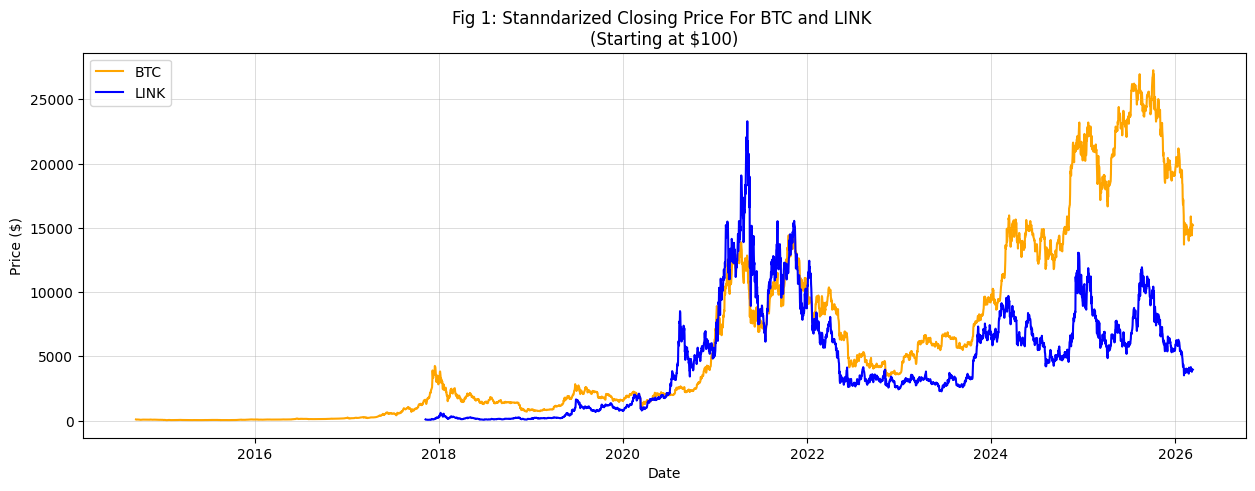

In [405]:

btc = btc_hist["scaled_close"] = (btc_hist["Close"] / btc_hist["Close"].iloc[0]) * 100
link = link_hist["scaled_close"] = (link_hist["Close"] / link_hist["Close"].iloc[0]) * 100

fig, ax = plt.subplots(1,1)
fig.set_size_inches(15,5)

ax.plot(btc, label="BTC", color="orange")
ax.plot(link, label="LINK", color="blue")

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.set_title("Fig 1: Stanndarized Closing Price For BTC and LINK \n(Starting at $100)")
ax.grid(True,  linewidth=0.5, alpha=0.6)
ax.legend()


## Data is clean and ready to go so now we can calculate the features.

- First ***Log Returns***

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

or more generaly

$$
r_t = \ln\left(\frac{P_{t+\Delta t}}{P_t}\right)
$$

Where:

- $r_t$ = log return at time $t$
- $P_t$ = asset price at time $t$
- $P_{t-1}$ = asset price at the previous time step
- $\ln$ = natural logarithm

In [406]:
# LINK
link_hist = link_hist.sort_index()
link_hist["t-1"] =  link_hist["Close"].shift(1)
link_hist["Log_returns"] = np.log ((link_hist["Close"] ) / (link_hist["t-1"])) 
link_hist = link_hist[["Close", "Log_returns", "Volume"]].dropna()
link_hist

,Close,Log_returns,Volume
Date,,,
2017-11-10 00:00:00+00:00,0.187602,-0.177185,2125460
2017-11-11 00:00:00+00:00,0.179770,-0.042644,2238980
2017-11-12 00:00:00+00:00,0.170898,-0.050611,5455200
2017-11-13 00:00:00+00:00,0.183071,0.068807,2992650
2017-11-14 00:00:00+00:00,0.188114,0.027174,2203410
...,...,...,...
2026-03-07 00:00:00+00:00,8.694978,-0.011286,418422310
2026-03-08 00:00:00+00:00,8.523437,-0.019926,547922531
2026-03-09 00:00:00+00:00,8.860023,0.038730,741942810


In [407]:
# BTC
btc_hist = btc_hist.sort_index()
btc_hist["t-1"] =  btc_hist["Close"].shift(1)
btc_hist["Log_returns"] = np.log ((btc_hist["Close"] ) / (btc_hist["t-1"])) 
btc_hist = btc_hist[["Close", "Log_returns", "Volume"]].dropna()
btc_hist

,Close,Log_returns,Volume
Date,,,
2014-09-18 00:00:00+00:00,424.440002,-0.074643,34483200
2014-09-19 00:00:00+00:00,394.795990,-0.072402,37919700
2014-09-20 00:00:00+00:00,408.903992,0.035111,36863600
2014-09-21 00:00:00+00:00,398.821014,-0.024968,26580100
2014-09-22 00:00:00+00:00,402.152008,0.008317,24127600
...,...,...,...
2026-03-07 00:00:00+00:00,67272.593750,-0.012760,23258701211
2026-03-08 00:00:00+00:00,65969.781250,-0.019556,33195080116
2026-03-09 00:00:00+00:00,68402.382812,0.036211,49499875378


## Now We Have To Calculate The 50-Day and 200-Day Moving Average (MA)

$$
SMA_{50}(t) = \frac{1}{50} \sum_{i=0}^{49} P_{t-i}
$$

$$
SMA_{200}(t) = \frac{1}{200} \sum_{i=0}^{199} P_{t-i}
$$

Where:

- $SMA_n(t)$ = Simple Moving Average over $n$ periods at time $t$
- $P_t$ = asset price at time $t$
- $n$ = number of periods included in the average



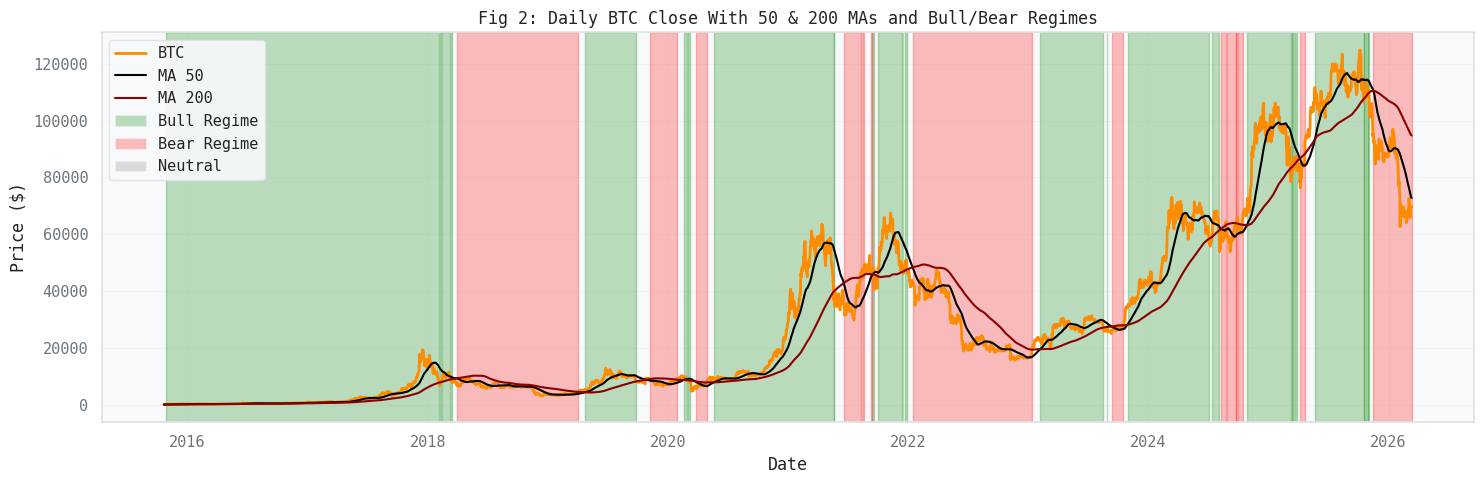

In [479]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

btc_hist["ma_50"] = btc_hist["Close"].rolling(window=50).mean()
btc_hist["ma_200"] = btc_hist["Close"].rolling(window=200).mean()
btc_hist.dropna(inplace=True)

btc_hist["Bull_Regime"] = (
    (btc_hist["Close"] > btc_hist["ma_200"]) &
    (btc_hist["ma_50"] > btc_hist["ma_200"])
)

btc_hist["Bear_Regime"] = (
    (btc_hist["Close"] < btc_hist["ma_200"]) &
    (btc_hist["ma_50"] < btc_hist["ma_200"])
)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 5)

def get_regime_color(idx):
    if btc_hist["Bull_Regime"].iloc[idx]:
        return "green"
    elif btc_hist["Bear_Regime"].iloc[idx]:
        return "red"
    else:
        return None  # neutral transition period

start_idx = btc_hist.index[0]
current_regime = get_regime_color(0)

for i in range(1, len(btc_hist)):
    new_regime = get_regime_color(i)
    if new_regime != current_regime:
        if current_regime is not None:
            ax.axvspan(start_idx, btc_hist.index[i], color=current_regime, alpha=0.25)
        start_idx = btc_hist.index[i]
        current_regime = new_regime

# Final segment
if current_regime is not None:
    ax.axvspan(start_idx, btc_hist.index[-1], color=current_regime, alpha=0.25)

# Price + moving averages
ax.plot(btc_hist.index, btc_hist["Close"], label="BTC", color="darkorange", linewidth=2)
ax.plot(btc_hist.index, btc_hist["ma_50"], label="MA 50", color="black", linewidth=1.5)
ax.plot(btc_hist.index, btc_hist["ma_200"], label="MA 200", color="darkred", linewidth=1.5)

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.set_title("Fig 2: Daily BTC Close With 50 & 200 MAs and Bull/Bear Regimes")
ax.grid(True, linewidth=0.5, alpha=0.6)

# Legend
bull_patch = Patch(facecolor="green", alpha=0.25, label="Bull Regime")
bear_patch = Patch(facecolor="red", alpha=0.25, label="Bear Regime")
neutral_patch = Patch(facecolor="grey", alpha=0.25, label="Neutral")
ax.legend(handles=ax.get_lines() + [bull_patch, bear_patch, neutral_patch], loc="upper left")
plt.tight_layout()
plt.show()

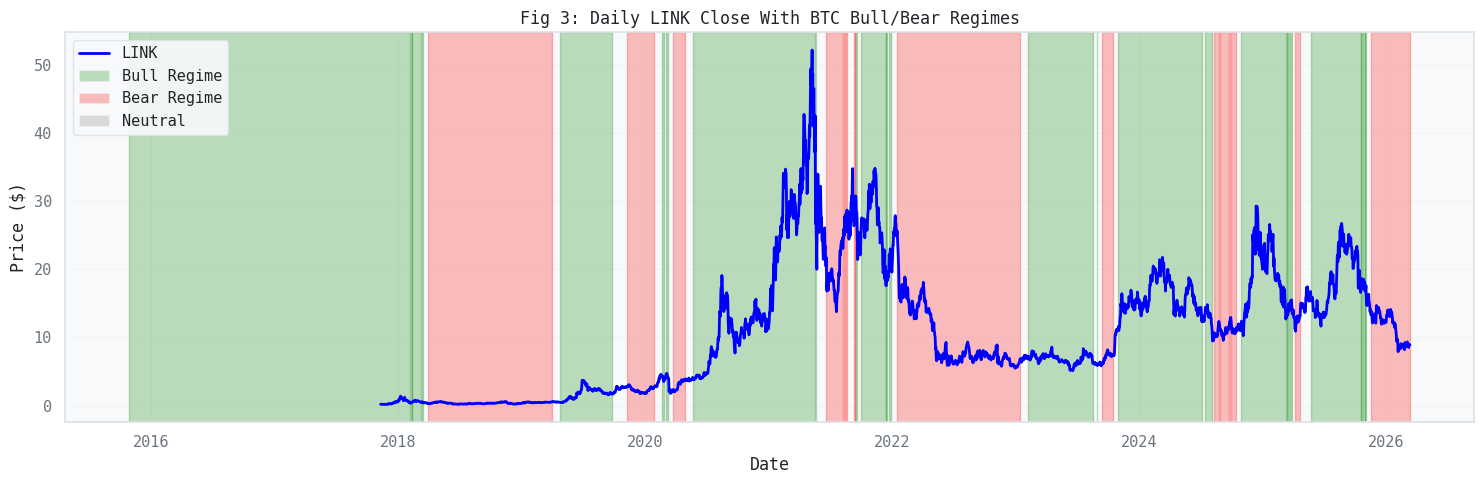

In [480]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 5)

def get_regime_color(idx):
    if btc_hist["Bull_Regime"].iloc[idx]:
        return "green"
    elif btc_hist["Bear_Regime"].iloc[idx]:
        return "red"
    else:
        return None

start_idx = btc_hist.index[0]
current_regime = get_regime_color(0)

for i in range(1, len(btc_hist)):
    new_regime = get_regime_color(i)
    if new_regime != current_regime:
        if current_regime is not None:
            ax.axvspan(start_idx, btc_hist.index[i], color=current_regime, alpha=0.25)
        start_idx = btc_hist.index[i]
        current_regime = new_regime

# Final segment
if current_regime is not None:
    ax.axvspan(start_idx, btc_hist.index[-1], color=current_regime, alpha=0.25)

# LINK price
ax.plot(link_hist.index, link_hist["Close"], label="LINK", color="blue", linewidth=2)

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.set_title("Fig 3: Daily LINK Close With BTC Bull/Bear Regimes")
ax.grid(True, linewidth=0.5, alpha=0.6)

# Legend
bull_patch = Patch(facecolor="green", alpha=0.25, label="Bull Regime")
bear_patch = Patch(facecolor="red", alpha=0.25, label="Bear Regime")
neutral_patch = Patch(facecolor="grey", alpha=0.25, label="Neutral")
ax.legend(handles=ax.get_lines() + [bull_patch, bear_patch, neutral_patch], loc="upper left")
plt.tight_layout()
plt.show()

# Finally We Can dive into the Data, First log returns

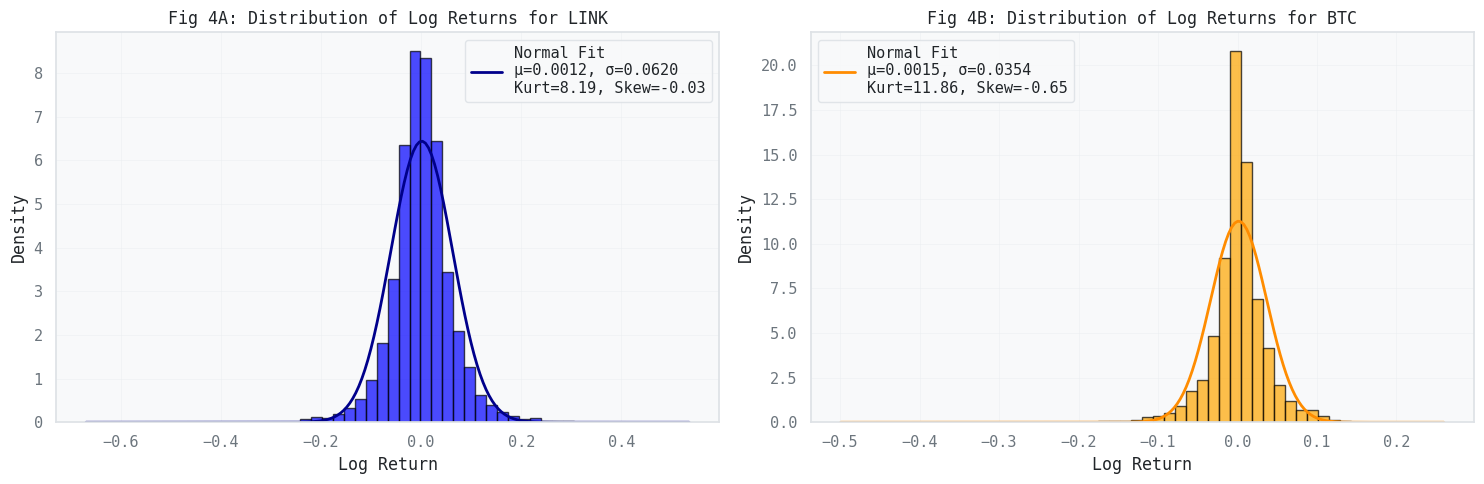

In [481]:
from scipy.stats import norm, kurtosis, skew

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(15, 5)

# =====================================================
#                   LINK GRAPH
# =====================================================
counts, bins, patches = ax[0].hist(link_hist["Log_returns"], density=True, bins=50, color="blue", edgecolor="black", alpha=0.7)

mu, std = norm.fit(link_hist["Log_returns"])
kurt = kurtosis(link_hist["Log_returns"])
sk = skew(link_hist["Log_returns"])

xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)

ax[0].plot(x, p, linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}\nKurt={kurt:.2f}, Skew={sk:.2f}", color="darkblue")
ax[0].set_xlabel("Log Return")
ax[0].set_ylabel("Density")
ax[0].set_title("Fig 4A: Distribution of Log Returns for LINK")
ax[0].grid(True, linewidth=0.5, alpha=0.6)
ax[0].legend()

# =====================================================
#                   BTC GRAPH
# =====================================================
counts, bins, patches = ax[1].hist(btc_hist["Log_returns"], density=True, bins=50, color="orange", edgecolor="black", alpha=0.7)

mu, std = norm.fit(btc_hist["Log_returns"])
kurt = kurtosis(btc_hist["Log_returns"])
sk = skew(btc_hist["Log_returns"])

xmin, xmax = ax[1].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)

ax[1].plot(x, p, linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}\nKurt={kurt:.2f}, Skew={sk:.2f}", color="darkorange")
ax[1].set_xlabel("Log Return")
ax[1].set_ylabel("Density")
ax[1].set_title("Fig 4B: Distribution of Log Returns for BTC")
ax[1].grid(True, linewidth=0.5, alpha=0.6)
ax[1].legend()

plt.tight_layout()  # added — prevents title/label overlap on subplots
plt.show()

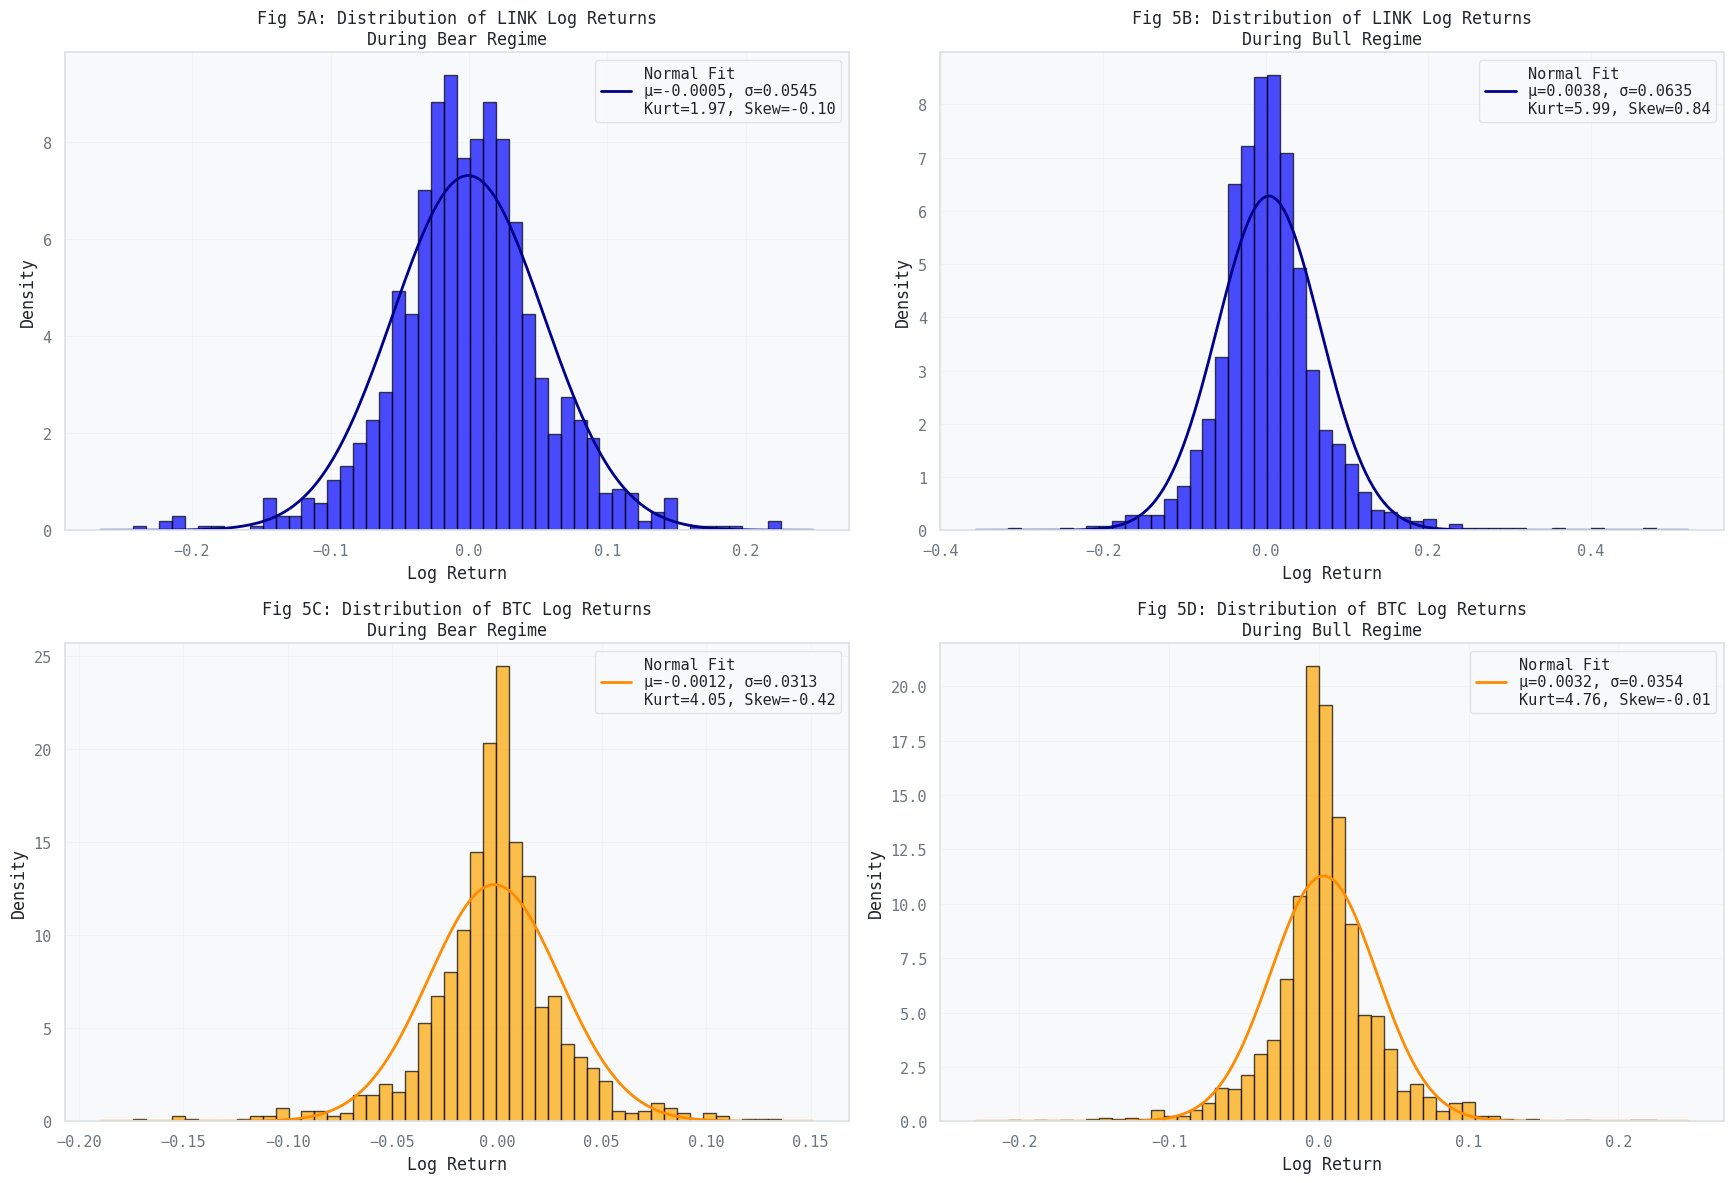

In [483]:
fig, ax = plt.subplots(2, 2, figsize=(17.5, 12))
ax = ax.ravel()

c = pd.merge(link_hist, btc_hist, left_index=True, right_index=True, how='left')

# =====================================================
#                   LINK GRAPH
# =====================================================

# LINK - Bear
bear = c[c["Bear_Regime"] == True]["Log_returns_x"].dropna()
counts, bins, patches = ax[0].hist(bear, density=True, bins=50, color="blue", edgecolor="black", alpha=0.7)
mu, std = norm.fit(bear)
kurt = kurtosis(bear)
sk = skew(bear)
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
ax[0].plot(x, norm.pdf(x, mu, std), linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}\nKurt={kurt:.2f}, Skew={sk:.2f}", color="darkblue")
ax[0].set_xlabel("Log Return")
ax[0].set_ylabel("Density")
ax[0].set_title("Fig 5A: Distribution of LINK Log Returns\nDuring Bear Regime")
ax[0].grid(True, linewidth=0.5, alpha=0.6)
ax[0].legend()

# LINK - Bull
bull = c[c["Bull_Regime"] == True]["Log_returns_x"].dropna()
counts, bins, patches = ax[1].hist(bull, density=True, bins=50, color="blue", edgecolor="black", alpha=0.7)
mu, std = norm.fit(bull)
kurt = kurtosis(bull)
sk = skew(bull)
xmin, xmax = ax[1].get_xlim()
x = np.linspace(xmin, xmax, 200)
ax[1].plot(x, norm.pdf(x, mu, std), linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}\nKurt={kurt:.2f}, Skew={sk:.2f}", color="darkblue")
ax[1].set_xlabel("Log Return")
ax[1].set_ylabel("Density")
ax[1].set_title("Fig 5B: Distribution of LINK Log Returns\nDuring Bull Regime")
ax[1].grid(True, linewidth=0.5, alpha=0.6)
ax[1].legend()

# =====================================================
#                   BTC GRAPH
# =====================================================

# BTC - Bear
bear = btc_hist[btc_hist["Bear_Regime"] == True]["Log_returns"].dropna()
counts, bins, patches = ax[2].hist(bear, density=True, bins=50, color="orange", edgecolor="black", alpha=0.7)
mu, std = norm.fit(bear)
kurt = kurtosis(bear)
sk = skew(bear)
xmin, xmax = ax[2].get_xlim()
x = np.linspace(xmin, xmax, 200)
ax[2].plot(x, norm.pdf(x, mu, std), linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}\nKurt={kurt:.2f}, Skew={sk:.2f}", color="darkorange")
ax[2].set_xlabel("Log Return")
ax[2].set_ylabel("Density")
ax[2].set_title("Fig 5C: Distribution of BTC Log Returns\nDuring Bear Regime")
ax[2].grid(True, linewidth=0.5, alpha=0.6)
ax[2].legend()

# BTC - Bull
bull = btc_hist[btc_hist["Bull_Regime"] == True]["Log_returns"].dropna()
counts, bins, patches = ax[3].hist(bull, density=True, bins=50, color="orange", edgecolor="black", alpha=0.7)
mu, std = norm.fit(bull)
kurt = kurtosis(bull)
sk = skew(bull)
xmin, xmax = ax[3].get_xlim()
x = np.linspace(xmin, xmax, 200)
ax[3].plot(x, norm.pdf(x, mu, std), linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}\nKurt={kurt:.2f}, Skew={sk:.2f}", color="darkorange")
ax[3].set_xlabel("Log Return")
ax[3].set_ylabel("Density")
ax[3].set_title("Fig 5D: Distribution of BTC Log Returns\nDuring Bull Regime")
ax[3].grid(True, linewidth=0.5, alpha=0.6)
ax[3].legend()

plt.tight_layout()
plt.show()

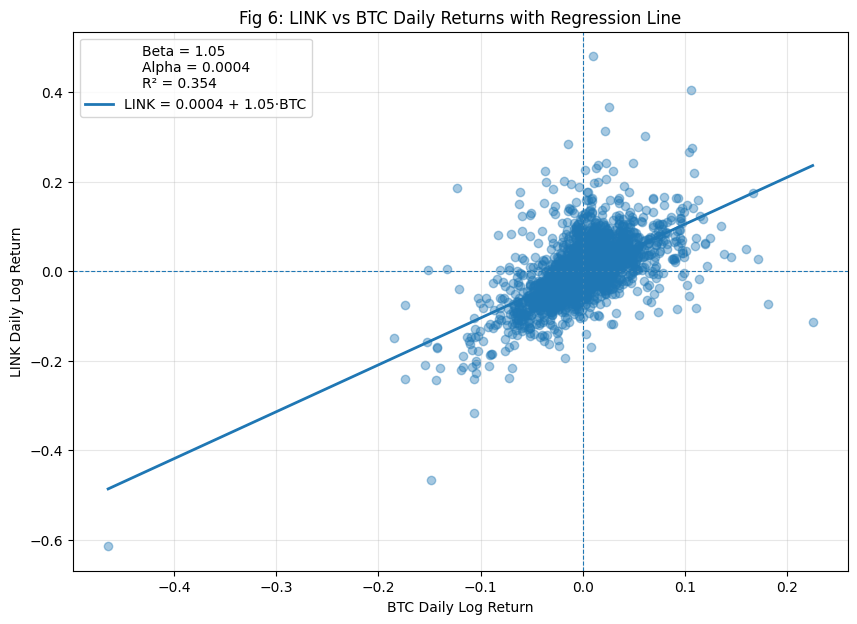

Alpha: 0.000426
Beta: 1.0477
R-squared: 0.3544
N: 3044


In [412]:
df = pd.DataFrame({
    "btc_ret": btc_hist["Log_returns"],
    "link_ret": link_hist["Log_returns"]
}).dropna()

# Linear regression: LINK = alpha + beta * BTC
beta, alpha = np.polyfit(df["btc_ret"], df["link_ret"], 1)

# R-squared
y_pred = alpha + beta * df["btc_ret"]
ss_res = np.sum((df["link_ret"] - y_pred) ** 2)
ss_tot = np.sum((df["link_ret"] - df["link_ret"].mean()) ** 2)
r2 = 1 - ss_res / ss_tot


plt.figure(figsize=(10, 7))
plt.scatter(df["btc_ret"], df["link_ret"], alpha=0.4)

x_line = np.linspace(df["btc_ret"].min(), df["btc_ret"].max(), 200)
y_line = alpha + beta * x_line
plt.plot(x_line, y_line, linewidth=2, label=f"LINK = {alpha:.4f} + {beta:.2f}·BTC")

plt.axhline(0, linewidth=0.8, linestyle="--")
plt.axvline(0, linewidth=0.8, linestyle="--")

plt.xlabel("BTC Daily Log Return")
plt.ylabel("LINK Daily Log Return")
plt.title("Fig 6: LINK vs BTC Daily Returns with Regression Line")
plt.legend(title=f"Beta = {beta:.2f}\nAlpha = {alpha:.4f}\nR² = {r2:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Alpha: {alpha:.6f}")
print(f"Beta: {beta:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"N: {len(df)}")

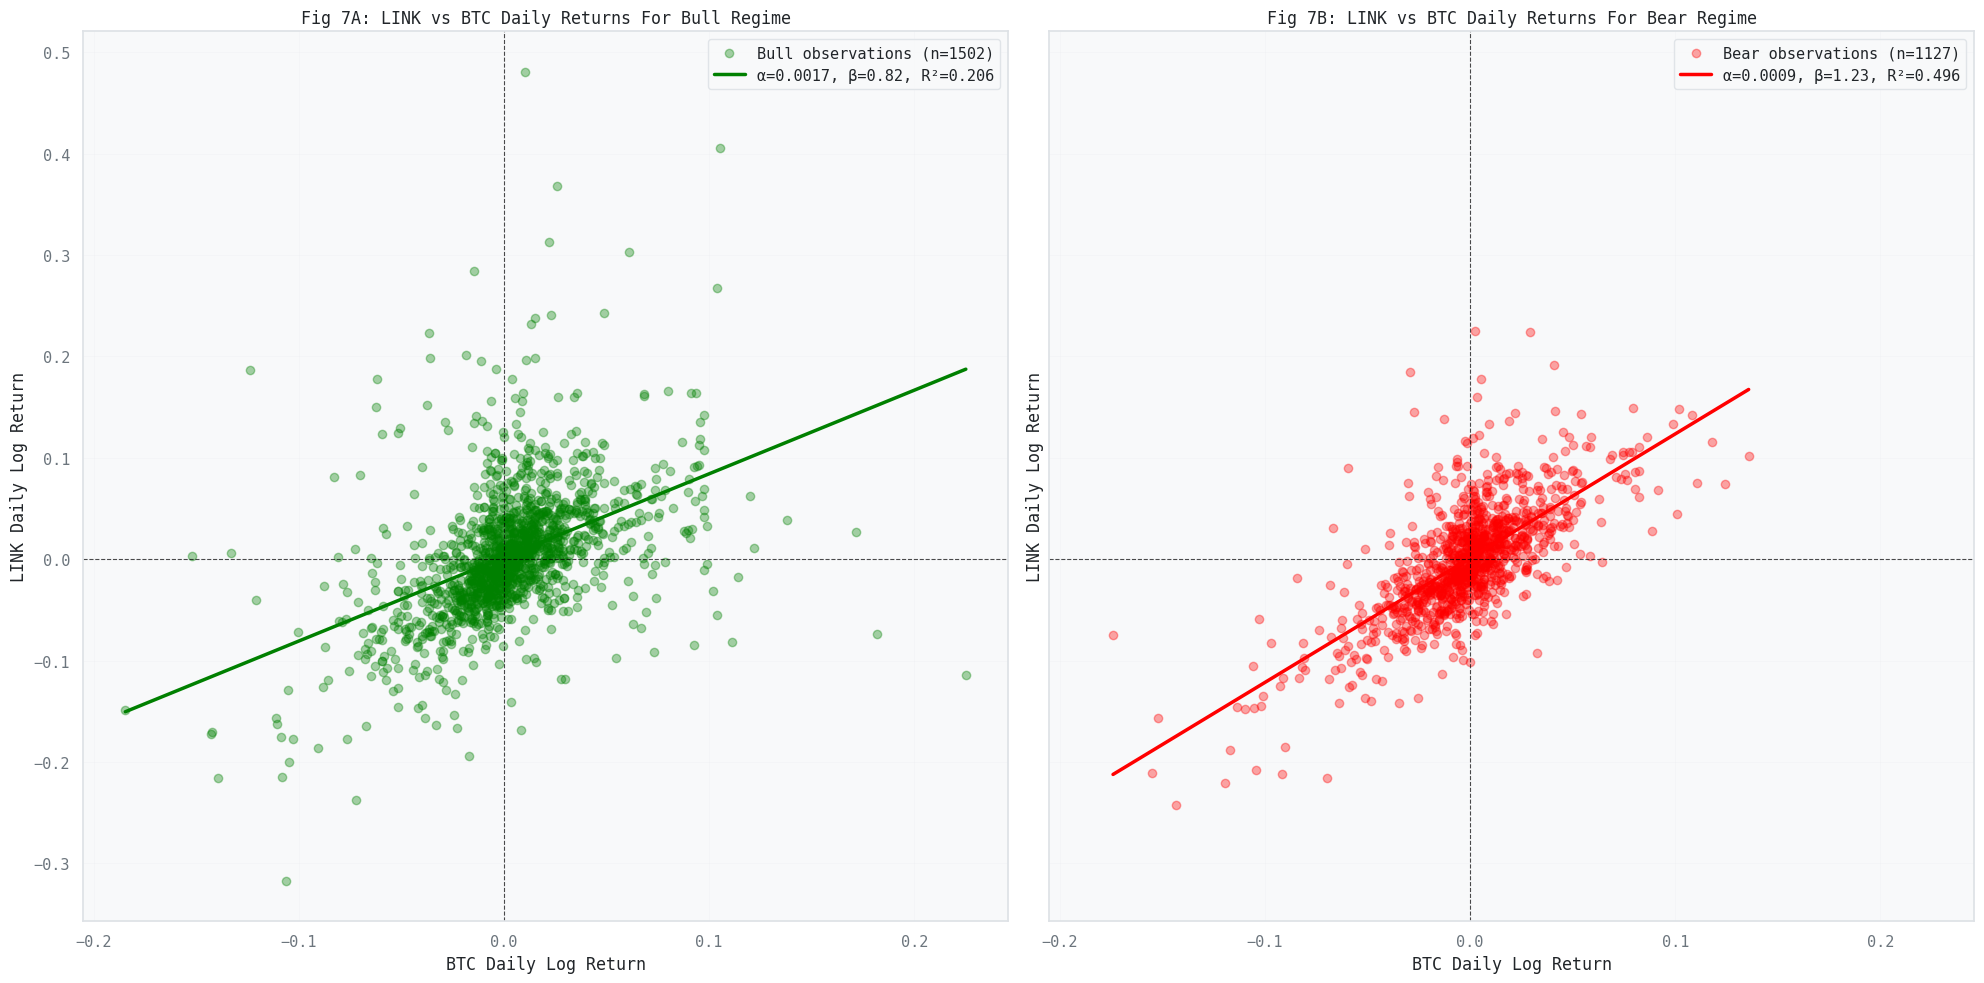

         alpha      beta        r2       n
Bull  0.001663  0.824646  0.206336  1502.0
Bear  0.000939  1.225415  0.495704  1127.0


In [484]:
df = pd.DataFrame({
    "btc_ret": btc_hist["Log_returns"],
    "link_ret": link_hist["Log_returns"],
    "regime": np.where(
        btc_hist["Bull_Regime"], "Bull",
        np.where(btc_hist["Bear_Regime"], "Bear", "Neutral")
    )
}).dropna()

# Exclude neutral periods
df = df[df["regime"] != "Neutral"]

regime_styles = {
    "Bull": {"color": "green", "alpha": 0.35},
    "Bear": {"color": "red", "alpha": 0.35}
}

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=True, sharey=True)

results = {}

for ax, regime in zip(axes, ["Bull", "Bear"]):
    sub = df[df["regime"] == regime].copy()

    x = sub["btc_ret"].values
    y = sub["link_ret"].values

    # Regression
    beta, alpha = np.polyfit(x, y, 1)
    y_pred = alpha + beta * x

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = alpha + beta * x_line

    # Scatter
    ax.scatter(
        x, y,
        alpha=regime_styles[regime]["alpha"],
        color=regime_styles[regime]["color"],
        label=f"{regime} observations (n={len(sub)})"
    )

    # Regression line
    ax.plot(
        x_line, y_line,
        color=regime_styles[regime]["color"],
        linewidth=2.5,
        label=f"α={alpha:.4f}, β={beta:.2f}, R²={r2:.3f}"
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_ylabel("LINK Daily Log Return")
    ax.grid(True, alpha=0.3)
    ax.legend()

    results[regime] = {
        "alpha": alpha,
        "beta": beta,
        "r2": r2,
        "n": len(sub)
    }

axes[1].set_xlabel("BTC Daily Log Return")
axes[0].set_xlabel("BTC Daily Log Return")

axes[0].set_title(f"Fig 7A: LINK vs BTC Daily Returns For Bull Regime")
axes[1].set_title(f"Fig 7B: LINK vs BTC Daily Returns For Bear Regime")

plt.tight_layout()
plt.show()

summary = pd.DataFrame(results).T
print(summary)

In [485]:
bear_link = df[df["regime"] == "Bear"]
bull_link = df[df["regime"] == "Bull"]

In [486]:
bear_link

,btc_ret,link_ret,regime
Date,,,
2018-03-30 00:00:00+00:00,-0.039159,0.025838,Bear
2018-03-31 00:00:00+00:00,0.011975,-0.025802,Bear
2018-04-01 00:00:00+00:00,-0.018716,-0.068660,Bear
2018-04-02 00:00:00+00:00,0.034405,0.045234,Bear
2018-04-03 00:00:00+00:00,0.051223,0.076603,Bear
...,...,...,...
2026-03-07 00:00:00+00:00,-0.012760,-0.011286,Bear
2026-03-08 00:00:00+00:00,-0.019556,-0.019926,Bear
2026-03-09 00:00:00+00:00,0.036211,0.038730,Bear


In [487]:
bull_link

,btc_ret,link_ret,regime
Date,,,
2017-11-10 00:00:00+00:00,-0.076400,-0.177185,Bull
2017-11-11 00:00:00+00:00,-0.040163,-0.042644,Bull
2017-11-12 00:00:00+00:00,-0.066248,-0.050611,Bull
2017-11-13 00:00:00+00:00,0.097510,0.068807,Bull
2017-11-14 00:00:00+00:00,0.011559,0.027174,Bull
...,...,...,...
2025-10-28 00:00:00+00:00,-0.010245,-0.020891,Bull
2025-10-29 00:00:00+00:00,-0.026017,0.015024,Bull
2025-10-31 00:00:00+00:00,0.011481,0.025574,Bull


### Geometric Brownian Motion (GBM)

The GBM price process is defined as:

$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t
$$

where:

- $S_t$ = asset price at time $t$
- $\mu$ = drift
- $\sigma$ = volatility
- $dW_t$ = Wiener process increment

The discrete-time solution used in Monte Carlo simulation is:

$$
S_{t+\Delta t} = S_t \exp\left[\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z_t\right]
$$

where:

- $\Delta t$ = time step
- $Z_t \sim \mathcal{N}(0,1)$

For simulation path $i$:

$$
S_{t+1}^{(i)} = S_t^{(i)} \exp\left[\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z_t^{(i)}\right]
$$

with initial condition:

$$
S_0 = \text{current LINK price}
$$

For regime-conditioned simulations:

$$
dS_t = \mu_{\text{bull}} S_t \, dt + \sigma_{\text{bull}} S_t \, dW_t
$$

$$
dS_t = \mu_{\text{bear}} S_t \, dt + \sigma_{\text{bear}} S_t \, dW_t
$$

In [509]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def monte_carlo_gbm(
    data,
    init_price,
    return_col="link_ret",
    look_back_days=365,
    num_paths=20000,
    years=5,
):

    # Pull most recent lookback window of returns
    rets = data[return_col].dropna().tail(look_back_days)

    if len(rets) < 2:
        raise ValueError("Not enough return observations after dropping NaNs.")

    # DAILY parameters
    mu = rets.mean()
    sigma = rets.std()

    # Total simulation steps in DAYS
    N = 365 * years

    # Pre-allocate path matrix
    price_paths = np.zeros((N + 1, num_paths))
    price_paths[0] = init_price

    # Simulate GBM using DAILY log-return parameters
    for t in range(1, N + 1):
        rand = np.random.standard_normal(num_paths)
        price_paths[t] = price_paths[t - 1] * np.exp(
            (mu - 0.5 * sigma**2) + sigma * rand
        )

    paths = pd.DataFrame(price_paths)

    # Percentile bands across all paths for each day
    p5 = paths.quantile(0.05, axis=1)
    p25 = paths.quantile(0.25, axis=1)
    p50 = paths.quantile(0.50, axis=1)
    p75 = paths.quantile(0.75, axis=1)
    p95 = paths.quantile(0.95, axis=1)
    mean_path = paths.mean(axis=1)

    # Checkpoints
    checkpoints = {
        "90D": 90,
        "1Y": 365,
        "3Y": 365 * 3,
        "5Y": 365 * 5
    }

    rows = []
    for label, idx in checkpoints.items():
        vals = paths.iloc[idx]
        rows.append({
            "Horizon": label,
            "5th %": vals.quantile(0.05),
            "25th %": vals.quantile(0.25),
            "Median": vals.quantile(0.50),
            "75th %": vals.quantile(0.75),
            "95th %": vals.quantile(0.95),
            "Mean": vals.mean()
        })

    summary_table = pd.DataFrame(rows)

    stats = {
        "mu_daily": mu,
        "sigma_daily": sigma,
        "mu_annual_approx": mu * 365,
        "sigma_annual_approx": sigma * np.sqrt(365),
        "p5": p5,
        "p25": p25,
        "p50": p50,
        "p75": p75,
        "p95": p95,
        "mean_path": mean_path
    }

    return paths, stats, summary_table

In [514]:
def plot_monte_carlo(
    paths,
    stats,
    init_price,
    title="Monte Carlo Simulation - LINK",
    max_paths_to_plot=500,
    ylim_percentile=97.5
):
    p5 = stats["p5"]
    p25 = stats["p25"]
    p50 = stats["p50"]
    p75 = stats["p75"]
    p95 = stats["p95"]
    mean_path = stats["mean_path"]

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("#f8f9fa")

    # Faint individual paths
    n_plot = min(max_paths_to_plot, paths.shape[1])
    ax.plot(paths.iloc[:, :n_plot], color="steelblue", alpha=0.015, linewidth=0.5)

    # Shaded confidence intervals
    ax.fill_between(paths.index, p5, p95, color="steelblue", alpha=0.12, label="90% CI (5th–95th)")
    ax.fill_between(paths.index, p25, p75, color="steelblue", alpha=0.25, label="50% CI (25th–75th)")

    # Percentile lines
    ax.plot(p5,        color="#d62728", linestyle="--", linewidth=1.2, label=f"5th pct   ${p5.iloc[-1]:.2f}")
    ax.plot(p25,       color="#ff7f0e", linestyle="--", linewidth=1.2, label=f"25th pct  ${p25.iloc[-1]:.2f}")
    ax.plot(p50,       color="#1f1f1f", linestyle="-",  linewidth=2.2, label=f"Median    ${p50.iloc[-1]:.2f}")
    ax.plot(p75,       color="#ff7f0e", linestyle="--", linewidth=1.2, label=f"75th pct  ${p75.iloc[-1]:.2f}")
    ax.plot(p95,       color="#d62728", linestyle="--", linewidth=1.2, label=f"95th pct  ${p95.iloc[-1]:.2f}")
    ax.plot(mean_path, color="#2ca02c", linestyle="-",  linewidth=1.8, label=f"Mean      ${mean_path.iloc[-1]:.2f}")

    # Start price
    ax.axhline(init_price, color="gray", linestyle=":", linewidth=1.4, label=f"Start     ${init_price:.2f}")

    # Y-axis clip
    y_max = np.percentile(paths.iloc[-1], ylim_percentile)
    ax.set_ylim(0, y_max * 1.50)

    # Vertical checkpoint markers
    checkpoints = [(90, "90D"), (365, "1Y"), (365 * 3, "3Y"), (365 * 5, "5Y")]
    for x, label in checkpoints:
        ax.axvline(x, color="gray", linestyle=":", linewidth=0.9, alpha=0.7)
        ax.text(x + 10, y_max * 1.02, label, ha="left", va="top", fontsize=8.5, color="gray")

    # Grid
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.set_axisbelow(True)

    # Labels
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Days", fontsize=11)
    ax.set_ylabel("Price (USD)", fontsize=11)

    # Legend — monospaced alignment, outside plot
    legend = ax.legend(
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
        edgecolor="lightgray",
        prop={"family": "monospace"},
        title="Percentile  |  5Y Price",
        title_fontsize=9
    )

    plt.tight_layout()
    plt.show()

---- Bear Regime Parameters ----
Daily mu:    -0.000812
Daily sigma: 0.040391
Annual mu:   -0.2965
Annual sigma:0.7717

---- Bear Regime Checkpoint Summary ----
  Horizon  5th %  25th %  Median  75th %  95th %  Mean
0     90D   4.07    5.93    7.70    9.92   14.45  8.26
1      1Y   1.37    2.85    4.86    8.23   17.48  6.60
2      3Y   0.16    0.60    1.49    3.70   13.59  3.73
3      5Y   0.03    0.14    0.45    1.43    7.68  2.03


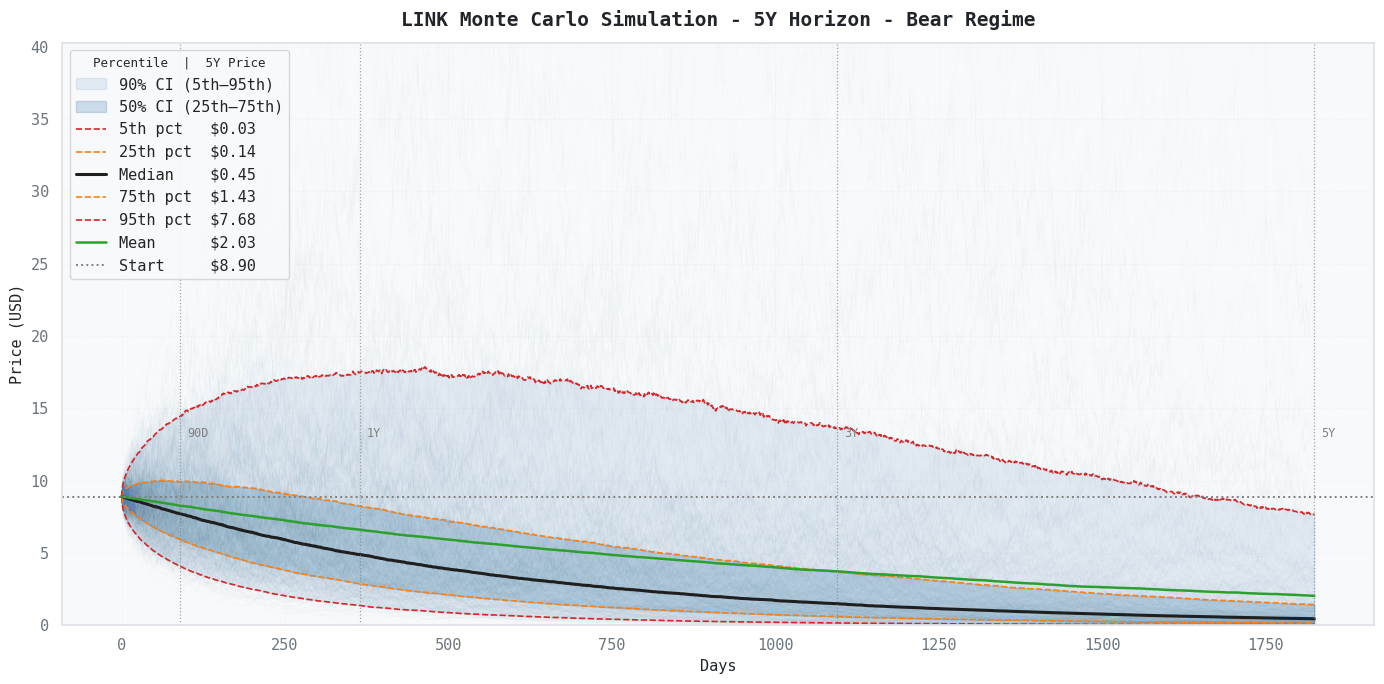

In [ ]:
# Make sure data is sorted oldest -> newest
bear_link = bear_link.sort_index()
link_hist = link_hist.sort_index()

# Current price
init_price = link_hist["Close"].iloc[-1]

paths_bear, stats_bear, summary_bear = monte_carlo_gbm(
    data=bear_link,
    init_price=init_price,
    return_col="link_ret",
    look_back_days=365,
    num_paths=20000,
    years=5
)

print("---- Bear Regime Parameters ----")
print(f"Daily mu:    {stats_bear['mu_daily']:.6f}")
print(f"Daily sigma: {stats_bear['sigma_daily']:.6f}")
print(f"Annual mu:   {stats_bear['mu_annual_approx']:.4f}")
print(f"Annual sigma:{stats_bear['sigma_annual_approx']:.4f}")

print("\n---- Bear Regime Checkpoint Summary ----")
print(summary_bear.round(2))

plot_monte_carlo(
    paths_bear,
    stats_bear,
    init_price=init_price,
    title="Fig 8: LINK Monte Carlo Simulation - 5Y Horizon - Bear Regime"
)


---- Bear Regime Parameters ----
Daily mu:    0.001548
Daily sigma: 0.051789
Annual mu:   0.5652
Annual sigma:0.9894

---- Bear Regime Checkpoint Summary ----
  Horizon  5th %  25th %  Median  75th %  95th %    Mean
0     90D   4.06    6.48    9.05   12.69   20.44   10.26
1      1Y   1.88    4.94    9.59   18.64   49.54   15.69
2      3Y   0.67    3.51   11.21   35.41  182.87   47.85
3      5Y   0.34    2.97   12.98   57.55  498.15  153.31


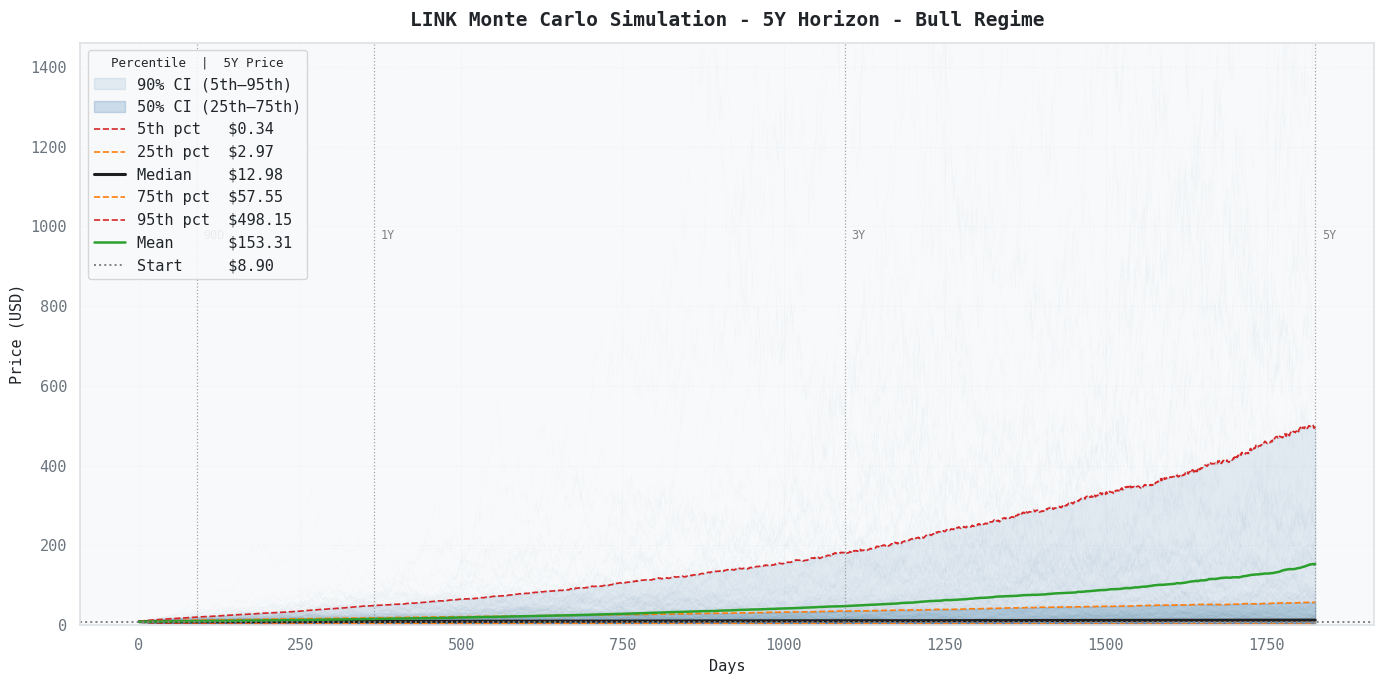

In [ ]:
# Make sure data is sorted oldest -> newest
bull_link = bull_link.sort_index()
link_hist = link_hist.sort_index()

# Current price
init_price = link_hist["Close"].iloc[-1]

paths_bull, stats_bull, summary_bull = monte_carlo_gbm(
    data=bull_link,
    init_price=init_price,
    return_col="link_ret",
    look_back_days=365,
    num_paths=20000,
    years=5
)

print("---- Bear Regime Parameters ----")
print(f"Daily mu:    {stats_bull['mu_daily']:.6f}")
print(f"Daily sigma: {stats_bull['sigma_daily']:.6f}")
print(f"Annual mu:   {stats_bull['mu_annual_approx']:.4f}")
print(f"Annual sigma:{stats_bull['sigma_annual_approx']:.4f}")

print("\n---- Bear Regime Checkpoint Summary ----")
print(summary_bull.round(2))

plot_monte_carlo(
    paths_bull,
    stats_bull,
    init_price=init_price,
    title="Fig 9: LINK Monte Carlo Simulation - 5Y Horizon - Bull Regime"
)


In [508]:
summary_bull.round(4)

,Horizon,5th %,25th %,Median,75th %,95th %,Mean
0,90D,4.0121,6.4788,9.0244,12.4969,20.1741,10.1479
1,1Y,1.8327,4.8327,9.3969,18.3068,48.6471,15.5152
2,3Y,0.6491,3.3732,11.0383,34.9214,184.6195,47.6590
3,5Y,0.3511,2.9241,12.6402,57.1143,497.2358,139.6983


In [506]:
summary_bear.round(4)

,Horizon,5th %,25th %,Median,75th %,95th %,Mean
0,90D,4.0948,5.9813,7.6874,9.9304,14.4370,8.2772
1,1Y,1.3910,2.9254,4.9141,8.2361,17.4311,6.6192
2,3Y,0.1663,0.6126,1.4891,3.6616,13.4120,3.6529
3,5Y,0.0269,0.1460,0.4540,1.4640,7.9338,2.0401
